In [ ]:
!pip install xlrd==2.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: xlrd
    Found existing installation: xlrd 2.0.2
    Uninstalling xlrd-2.0.2:
      Successfully uninstalled xlrd-2.0.2


# Objetivo: Este código de teste para aplicar varmax adicionando manualmente o número de lagas para teste, grau de polinômios (exógenas e endógena) e também tenta adicionar às influências das partes reais e imaginárias

In [ ]:
# ---------------------
# Incluindo Bibliotecas
# ---------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VARMAX
from statsmodels.tsa.stattools import coint,kpss
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from itertools import product,combinations

In [ ]:
# ----------------------------------
# Função de detecção de cointegração
# ----------------------------------
def detect_cointegration(df,significance=0.05,verbose=False) -> list:
    """
    Testa cointegração par a par entre todas as séries.
    Retorna True se qualquer par for cointegrado.
    """
    cols = df.columns.tolist()
    cointegrated_pairs = []

    for c1, c2 in combinations(cols, 2):
        s1 = df[c1].dropna().astype(float)
        s2 = df[c2].dropna().astype(float)
        idx = s1.index.intersection(s2.index)
        try:
            _, p_value, _ = coint(s1.loc[idx], s2.loc[idx])
            if p_value < significance:
                cointegrated_pairs.append((c1, c2, p_value))
                if verbose:
                    print(f"  Cointegrados: {c1} x {c2} | p={p_value:.4f}")
        except Exception:
            pass

    return cointegrated_pairs

In [ ]:
# ----------------------------------------------------
# Função de verificação de estácionaridade kpss_test()
# ----------------------------------------------------
def kpss_test(serie,verbose=False) -> bool:
  kpss_serie = kpss(serie)

  if(verbose):
    print(f"  Test statitics  : {kpss_serie[0]}")
    print(f"  Test p_value    : {kpss_serie[1]}")
    print(f"  Number of lags  : {kpss_serie[2]}")
    print(f"  Critical values :")

    for key,val in kpss_serie[3].items():
      print(f"    {key} : {val}")

  return kpss_serie

In [ ]:
def detect_d_varmax(df_train, seasonal_period=None, verbose=False):
    """
    Detecta d e D para cada série do VARMAX.
    Retorna dict com d por coluna, D comum, e pares cointegrados.
    """
    d_dict = {}
    D_dict = {}

    for col in df_train.columns:
        serie = df_train[col].dropna().astype(float)
        d, D = detect_d_D(serie, seasonal_period=seasonal_period, verbose=False)
        d_dict[col] = d
        D_dict[col] = D
        if verbose:
            print(f"  {col}: d={d}, D={D}")

    # Verificar cointegração apenas entre séries I(1)
    cols_i1 = [c for c, v in d_dict.items() if v == 1]
    coint_pairs = []
    if len(cols_i1) >= 2:
        if verbose:
            print(f"\nTestando cointegração entre séries I(1): {cols_i1}")
        coint_pairs = detect_cointegration(
            df_train[cols_i1],
            verbose=verbose
        )

    # d comum conservador (máximo entre as séries)
    d_common = max(d_dict.values()) if d_dict else 0
    D_common = max(D_dict.values()) if D_dict else 0

    if verbose:
        print(f"\nd comum: {d_common} | D comum: {D_common}")
        if coint_pairs:
            print(f"⚠️  {len(coint_pairs)} par(es) cointegrado(s) — considere VECM")
        else:
            print("✓ Sem cointegração detectada — VARMAX com diferenciação é adequado")

    return {
        "d_by_col": d_dict,
        "D_by_col": D_dict,
        "d_common": d_common,
        "D_common": D_common,
        "cointegrated_pairs": coint_pairs
    }

In [ ]:
# ---------------------------------------
# Função de Criação Automática de Lag (m)
# ---------------------------------------
def select_auto_lag(df_exog,exog_cols,max_x_lag=2,inplace=True) -> pd.DataFrame:
  """
  Aplica os lags desejado às exógenas da base de dados original e retorna o dataframe com as novas colunas
  """
  new_exog_cols = list(exog_cols)

  for lag in range(1, max_x_lag + 1):
    for col in exog_cols:
      lag_cols_name = f'{col}_lag{lag}'
      df_exog[lag_cols_name] = df_exog[col].shift(lag)
      new_exog_cols.append(lag_cols_name)

  lag_cols = [f'{col}_lag{lag}' for lag in range(1, max_x_lag+1) for col in exog_cols]
  rows_to_drop = df_exog.index[df_exog[lag_cols].isna().any(axis=1)]

  df_exog = df_exog.drop(index=rows_to_drop)
  return df_exog,new_exog_cols

In [ ]:
# -------------------------------------------------
# Função de Seleção de grau de Polinômio de Lag (m)
# -------------------------------------------------
def select_auto_polinomial_degree(df_exog,exog_cols,degree_type,max_degree=1) -> pd.DataFrame:
  """
  Aplica os graus desejado às exógenas da base de dados original, gerando o polinômio completo para cada coluna
  das exógenas (originais e sem lags) e retorna o dataframe com as novas colunas
  """
  new_exog_cols = list(exog_cols)
  new_columns = {}

  if degree_type in ['real','r','REAL','Real']:
    degree_type = 'real'
  elif degree_type in ['img','i','IMG','Img']:
    degree_type = 'img'
  else:
    raise ValueError("degree_type must be 'real' or 'img'")

  # Aplicando graus para série de dados reais
  if max_degree >= 2:
    for degree in range(2, max_degree + 1):
      columns = [col for col in exog_cols if degree_type in col]
      for col in columns:
        degree_col_name = f'{col}_deg{degree}'
        new_columns[degree_col_name] = df_exog[col] ** degree
        new_exog_cols.append(degree_col_name)

  if new_columns:
    df_exog = pd.concat([df_exog,pd.DataFrame(new_columns,index=df_exog.index)],axis=1)

  return df_exog,new_exog_cols

In [ ]:
# -----------------------------------------
# Função de Forecast e Cálculo das Métricas
# -----------------------------------------
def get_forecast_metrics(p, res, val, endog_cols, current_exog_cols) -> dict:
    """
    Calcula as métricas de avaliação da previsão realizada pelo modelo
    """
    fc = res.forecast(steps=len(val[list(endog_cols)]), exog=val[current_exog_cols])
    metrics = {}

    for col in endog_cols:
        y_true = val[col]
        y_pred = fc[col]

        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - p - 1)
        std_err = np.std(y_true - y_pred)

        metrics[col] = {
          'MSE':    mse,
          'RMSE':   rmse,
          'MAE':    mae,
          'R2':     r2,
          'AdjR2':  adj_r2,
          'STD':    std_err,
        }

    # Métricas globais do modelo
    metrics['rmse_mean'] = np.mean([metrics[col]['RMSE'] for col in endog_cols])
    metrics['aic'] = getattr(res, 'aic', np.nan)
    metrics['bic'] = getattr(res, 'bic', np.nan)

    return metrics

In [ ]:
# -----------------------------
# Função de Impressão dos Dados
# -----------------------------
def view_result(data,endog_cols=('Yreal', 'Yimg')):
    """
    Imprime na tela as métricas calculadas de acordo com a previsão do modelo
    """
    metric_labels = [
        ('RMSE',  'RMSE'),
        ('MAE',   'MAE'),
        ('R2',    'R²'),
        ('AdjR2', 'R² Ajust'),
        ('STD',   'STD')]

    W_METRIC = 10
    W_VAL    = 10

    def sep(l, m, r, n_cols):
        block = '─' * (W_METRIC + W_VAL + 3)
        return l + m.join([block] * n_cols) + r

    def row_str(pairs):
        cells = [f' {lbl:<{W_METRIC}} {val:>{W_VAL}} ' for lbl, val in pairs]
        return '│' + '│'.join(cells) + '│'

    print(f'Lag={data["p"]}')
    print(f'  AIC={data["aic"]:.2f} | BIC={data["bic"]:.2f} | RMSE Mean={data["rmse_mean"]:.4f}')
    print(f'  X Lag={data["x_lag"]} | Exog Degree={data["exog_degree"]}')

    print(sep('  ┌', '┬', '┐', len(endog_cols)))
    print('  ' + row_str([(col, '') for col in endog_cols]))
    print(sep('  ├', '┼', '┤', len(endog_cols)))

    for key, lbl in metric_labels:
        pairs = []
        for col in endog_cols:
            val = data[col][key]
            v_str = f'{val:+.4f}' if key in ('R2', 'AdjR2') else f'{val:.4f}'
            pairs.append((lbl, v_str))
        print('  ' + row_str(pairs))

    print(sep('  └', '┴', '┘', len(endog_cols)))

In [ ]:
# -------------------------------------
# Função de Seleção de Teste de Lag (m)
# -------------------------------------
def calc_train_sect(data:pd.DataFrame,train_frac:float,val_frac:float):
  """
  Calcula o tamanho dos conjuntos de treino, validação e teste
  """
  n = len(data)
  train_end = int(n*train_frac)
  val_end = int(n*(train_frac + val_frac))
  return train_end,val_end

def gridsearch_custom_varmax(
    data:pd.DataFrame,
    endog_cols:list,
    exog_cols:list,
    max_p:int=3,
    max_x_lag:int=2,
    train_frac:float=0.6,
    val_frac:float=0.2,
    endog_real_degree:int=0,
    endog_img_degree:int=0,
    exog_real_degree:int=0,
    exog_img_degree:int=0,
    trends:list=['c'],
    verbose:bool=True) -> pd.DataFrame:
  """
  Busca a melhor combinação de hiperparâmetros para o modelo VARMAX com base nas métricas de avaliação (RMSE,AIC,BIC)
  """
  train_end,val_end = calc_train_sect(data,train_frac,val_frac)
  results = []

  for p in range(1, max_p + 1):
    for x_lag in range(0, max_x_lag + 1):
      for tr in trends:
        df_temp = data.copy()
        current_exog_cols = list(exog_cols)

        if x_lag > 0:
          df_temp,current_exog_cols = select_auto_lag(df_temp,exog_cols,max_x_lag=x_lag)

        degree_combination = list(product(range(1,exog_real_degree+1),range(1,exog_img_degree+1)))

        if not degree_combination and (exog_real_degree == 0 or exog_img_degree == 0):
            degree_combination = [(1, 1)]

        for real,img in degree_combination:
          _df_temp = df_temp.copy()
          train_exog_cols = list(current_exog_cols)

          if real >= 2:
            _df_temp, train_exog_cols = select_auto_polinomial_degree(_df_temp,train_exog_cols,'r',max_degree=real)

          if img >= 2:
            _df_temp, train_exog_cols = select_auto_polinomial_degree(_df_temp,train_exog_cols,'i',max_degree=img)

          train = _df_temp.iloc[:train_end].copy()
          val = _df_temp.iloc[train_end:val_end].copy()
          test = _df_temp.iloc[val_end:].copy()

          try:
            model = VARMAX(
                    train[list(endog_cols)],
                    exog=train[train_exog_cols],
                    order=(p, 0),
                    trend=tr)
            res = model.fit(disp=False,maxiter=500,method='powell')
            dict_res = get_forecast_metrics(p,res,val,endog_cols,train_exog_cols)
            dict_res.update({'p':p,'x_lag':x_lag,'exog_degree':f"(r:{real},i:{img})",'trend':tr})

            if verbose: view_result(dict_res)

          except Exception as e:
            print(f"Erro ao treinar o modelo: {e}")
            continue

  return pd.DataFrame(results)

## Leitura dos dataframes iniciais

In [ ]:
data = "dadosIniciais.xlsx"
data = pd.read_excel(data)

In [ ]:
df_input = pd.DataFrame()
df_input["Xreal"] = data.iloc[:,0]
df_input["Ximg"] = data.iloc[:,1]

In [ ]:
df_output = pd.DataFrame()
df_output["Yreal"] = data.iloc[:,2]
df_output["Yimg"] = data.iloc[:,3]

In [ ]:
df_concat = pd.concat([df_output,df_input],axis=1)

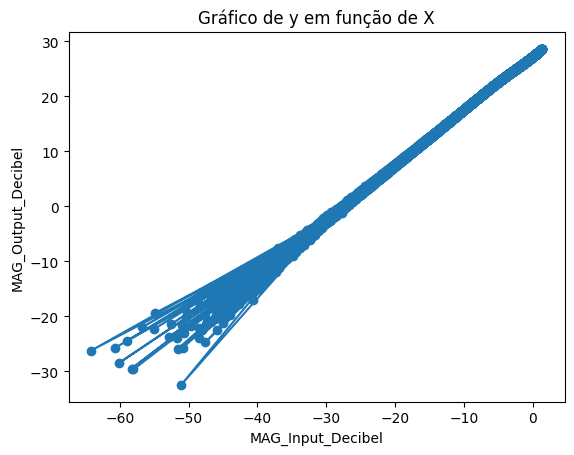

In [ ]:
df_mag = pd.DataFrame()
df_mag["MAG_Input"] = np.sqrt(df_concat["Xreal"]**2 + df_concat["Ximg"]**2)
df_mag["MAG_Output"] = np.sqrt(df_concat["Yreal"]**2 + df_concat["Yimg"]**2)

df_mag["MAG_Input_Decibel"]= 20 * np.log10(df_mag["MAG_Input"])
df_mag["MAG_Output_Decibel"]= 20 * np.log10(df_mag["MAG_Output"])

df_mag["MAG_Input_Decibel"]= df_mag["MAG_Input_Decibel"]
df_mag["MAG_Output_Decibel"]= df_mag["MAG_Output_Decibel"]

plt.plot(df_mag["MAG_Input_Decibel"], df_mag["MAG_Output_Decibel"], marker='o')
plt.xlabel('MAG_Input_Decibel')
plt.ylabel('MAG_Output_Decibel')
plt.title('Gráfico de y em função de X')
plt.show()

## Verificação propriedades de estácionariadade

In [ ]:
yreal_serie = df_output["Yreal"].dropna().astype(float)
yimg_serie = df_output["Yimg"].dropna().astype(float)

print(f"Applying KPSS on Yreal Serie:")
kpss_test(yreal_serie,verbose=True)

print(f"\nApplying KPSS on Yimg Serie:")
kpss_test(yimg_serie,verbose=True)

Applying KPSS on Yreal Serie:
  Test statitics  : 0.0016847730360583346
  Test p_value    : 0.1
  Number of lags  : 109
  Critical values :
    10% : 0.347
    5% : 0.463
    2.5% : 0.574
    1% : 0.739

Applying KPSS on Yimg Serie:
  Test statitics  : 0.005354282300515851
  Test p_value    : 0.1
  Number of lags  : 109
  Critical values :
    10% : 0.347
    5% : 0.463
    2.5% : 0.574
    1% : 0.739


/tmp/ipykernel_5347/1605327739.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_serie = kpss(serie)
/tmp/ipykernel_5347/1605327739.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_serie = kpss(serie)


(np.float64(0.005354282300515851),
 np.float64(0.1),
 109,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

## Teste de geração de lags

In [ ]:
current_exog_cols = ["Xreal","Ximg"]
cp_df_input = df_input.copy()
cp_df_input, current_exog_cols = select_auto_lag(cp_df_input,current_exog_cols,max_x_lag=5,inplace=False)

print(f"current_exog_cols: {current_exog_cols}")

current_exog_cols: ['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_lag3', 'Ximg_lag3', 'Xreal_lag4', 'Ximg_lag4', 'Xreal_lag5', 'Ximg_lag5']


## Teste de Geração de Graus de Polinômio

In [ ]:
exog_cols = cp_df_input.columns
current_exog_cols = list(exog_cols)
cp_df_input, current_exog_cols = select_auto_polinomial_degree(cp_df_input,exog_cols,'r',max_degree=3)

print(f"{[col for col in list(cp_df_input.columns) if 'X' in col]}")
print(f"current_exog_cols: {current_exog_cols}")

['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_lag3', 'Ximg_lag3', 'Xreal_lag4', 'Ximg_lag4', 'Xreal_lag5', 'Ximg_lag5', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_lag3_deg2', 'Xreal_lag4_deg2', 'Xreal_lag5_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Xreal_lag3_deg3', 'Xreal_lag4_deg3', 'Xreal_lag5_deg3']
current_exog_cols: ['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Xreal_lag2', 'Ximg_lag2', 'Xreal_lag3', 'Ximg_lag3', 'Xreal_lag4', 'Ximg_lag4', 'Xreal_lag5', 'Ximg_lag5', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_lag3_deg2', 'Xreal_lag4_deg2', 'Xreal_lag5_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Xreal_lag3_deg3', 'Xreal_lag4_deg3', 'Xreal_lag5_deg3']


In [ ]:
real_exog_cols = [col for col in current_exog_cols if 'real' in col]
img_exog_cols = [col for col in current_exog_cols if 'img' in col]

print(f"real_exog_cols: {real_exog_cols}")
print(f"img_exog_cols: {img_exog_cols}")

real_exog_cols: ['Xreal', 'Xreal_lag1', 'Xreal_lag2', 'Xreal_lag3', 'Xreal_lag4', 'Xreal_lag5', 'Xreal_deg2', 'Xreal_lag1_deg2', 'Xreal_lag2_deg2', 'Xreal_lag3_deg2', 'Xreal_lag4_deg2', 'Xreal_lag5_deg2', 'Xreal_deg3', 'Xreal_lag1_deg3', 'Xreal_lag2_deg3', 'Xreal_lag3_deg3', 'Xreal_lag4_deg3', 'Xreal_lag5_deg3']
img_exog_cols: ['Ximg', 'Ximg_lag1', 'Ximg_lag2', 'Ximg_lag3', 'Ximg_lag4', 'Ximg_lag5']


## Testando a correlação entre as Séries Endógenas

In [ ]:
cp_df_output = df_output.copy()
res = detect_cointegration(cp_df_output,verbose=True)

print(f"Detect cointegration response: {res}")

  Cointegrados: Yreal x Yimg | p=0.0000
Detect cointegration response: [('Yreal', 'Yimg', 0.0)]


## Teste da Seleção de Lags do Varmax

In [ ]:
search = False
endog_cols = ["Yreal","Yimg"]
exog_cols = ["Xreal","Ximg"]

if search:
  res = gridsearch_custom_varmax(
      data=df_concat,
      endog_cols=endog_cols,
      exog_cols=exog_cols,
      max_p=3,
      exog_real_degree=2,
      exog_img_degree=2)

  view_result(res.sort_values(by="rmse"))

## Teste de Treinamento do Modelo e Visualização dos Dados

In [ ]:
# ----------------------------------------
# Treinamento do Modelo VARMAX customizado
# ----------------------------------------
def custom_train_varmax(
    df_train:pd.DataFrame,
    endog_lag,
    exog_lag,
    exog_img_degree,
    exog_real_degree,
    train_frac=0.6,
    val_frac=0.2,
    endog_cols=("Yreal","Yimg"),
    exog_cols=("Xreal", "Ximg")) -> VARMAX:
  """
  Treina o modelo VARMAX com base nos parâmetros fornecidos de lags para endógenas e exógenas e também
  com os graus dos polinômios de exógenas (real e imaginária)
  """
  train_end,val_end = calc_train_sect(df_train,train_frac,val_frac)
  df_temp = df_train.copy()
  current_exog_cols = list(exog_cols)

  if exog_lag > 0:
    df_temp,current_exog_cols = select_auto_lag(df_temp,exog_cols,max_x_lag=exog_lag)

  if exog_real_degree >= 2:
    df_temp, current_exog_cols = select_auto_polinomial_degree(df_temp,current_exog_cols,'r',max_degree=exog_real_degree)

  if exog_img_degree >= 2:
    df_temp, current_exog_cols = select_auto_polinomial_degree(df_temp,current_exog_cols,'i',max_degree=exog_img_degree)

  train = df_temp.iloc[:train_end].copy()
  val = df_temp.iloc[train_end:val_end].copy()
  test = df_temp.iloc[val_end:].copy()

  model = VARMAX(
          train[list(endog_cols)],
          exog=train[current_exog_cols],
          order=(endog_lag, 0),
          trend='c')

  res = model.fit(disp=False,maxiter=500,method="powell")

  return res,df_temp,current_exog_cols

In [ ]:
# ---------------------------------
# Geração dos Mapas de Constelações
# ---------------------------------
def drawn_constellation_map(forecast,endog_cols=('Yreal','Yimg'),title="Mapa de Constelação"):
  plt.figure(figsize=(6,6))
  plt.scatter(forecast[endog_cols[0]],forecast[endog_cols[1]],s=1,color='blue')
  plt.title(f"{title} - {endog_cols}")
  plt.xlabel("In-phase (I) [Y-Real]")
  plt.ylabel("Quadrature (Q) [Y-Img]")
  plt.grid(True)
  plt.axhline(0,color='black',lw=1)
  plt.axvline(0,color='black',lw=1)
  img_label = title.replace(" ","-").lower()
  plt.savefig(f"{img_label}.png")
  plt.show()

In [ ]:
# Treinando modelo com os seguintes parâmetros (tempo de aproximadamente 53 min)
# p=1, xlag = 1, x_real_degree = 1, x_img_degree = 2
endog_cols = ["Yreal","Yimg"]
exog_cols =  ["Xreal","Ximg"]

res,df_train_test,current_exog_cols = custom_train_varmax(
    df_train=df_concat,
    endog_lag=1,
    exog_lag=1,
    exog_img_degree=2,
    exog_real_degree=1)

## Gerando métricas (forecast) e gráficos para conjuntos de treino, validação e teste

In [ ]:
# Preparando DataFrames
train_end,val_end = calc_train_sect(df_train_test,0.6,0.2)
train = df_train_test.iloc[:train_end].copy()
val = df_train_test.iloc[train_end:val_end].copy()
test = df_train_test.iloc[val_end:].copy()

print(f"train: {train.shape} | val: {val.shape} | test: {test.shape}")
print(f"tran.columns: {train.columns} | val.columns: {val.columns} | test.columns: {test.columns}")
print(f"current exog cols: {current_exog_cols}")

train: (29029, 8) | val: (9676, 8) | test: (9677, 8)
tran.columns: Index(['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1',
       'Ximg_deg2', 'Ximg_lag1_deg2'],
      dtype='object') | val.columns: Index(['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1',
       'Ximg_deg2', 'Ximg_lag1_deg2'],
      dtype='object') | test.columns: Index(['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1',
       'Ximg_deg2', 'Ximg_lag1_deg2'],
      dtype='object')
current exog cols: ['Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Ximg_deg2', 'Ximg_lag1_deg2']


In [ ]:
# Realizando forecast dos dados de treino,validação e teste (tempo de aproximada 1 min)
fc_train = res.forecast(steps=len(train[list(endog_cols)]),exog=train[current_exog_cols])
fc_val = res.forecast(steps=len(val[list(endog_cols)]),exog=val[current_exog_cols])
fc_test = res.forecast(steps=len(test[list(endog_cols)]),exog=test[current_exog_cols])

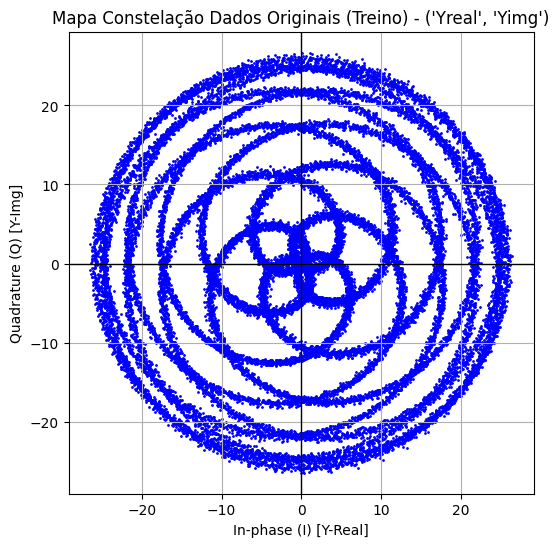

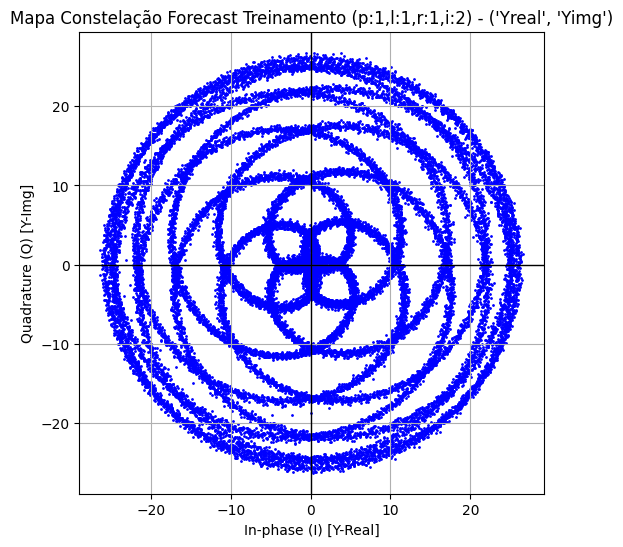

In [ ]:
# Mapas de Constelação dos dados de Treino Reias e Forecast
drawn_constellation_map(train,title="Mapa Constelação Dados Originais (Treino)")
drawn_constellation_map(fc_train,title="Mapa Constelação Forecast Treinamento (p:1,l:1,r:1,i:2)")

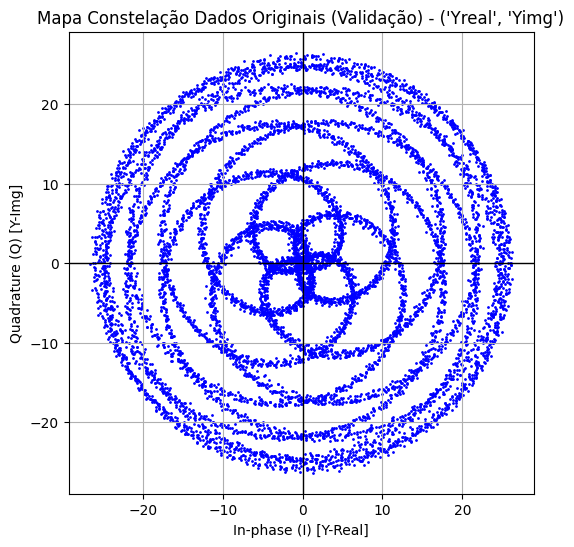

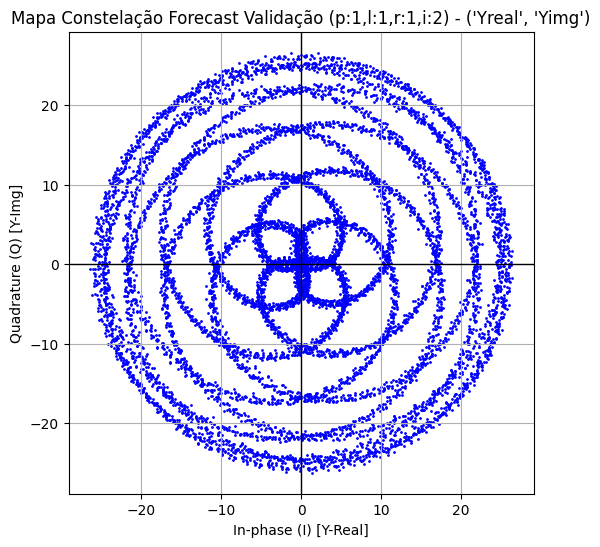

In [ ]:
# Mapas de Constelação dos dados de Validação Reais e Forecast
drawn_constellation_map(val,title="Mapa Constelação Dados Originais (Validação)")
drawn_constellation_map(fc_val,title="Mapa Constelação Forecast Validação (p:1,l:1,r:1,i:2)")

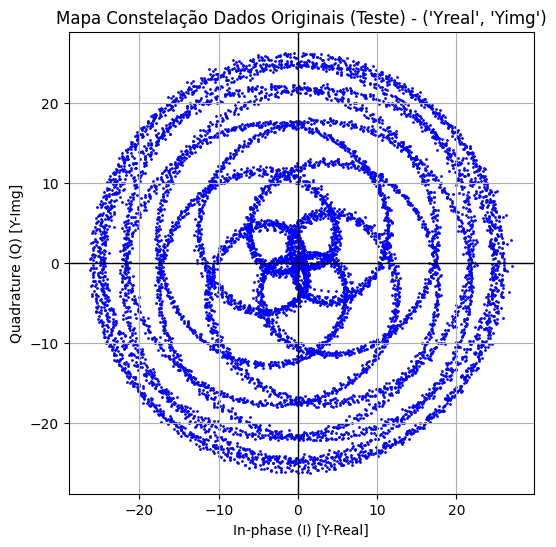

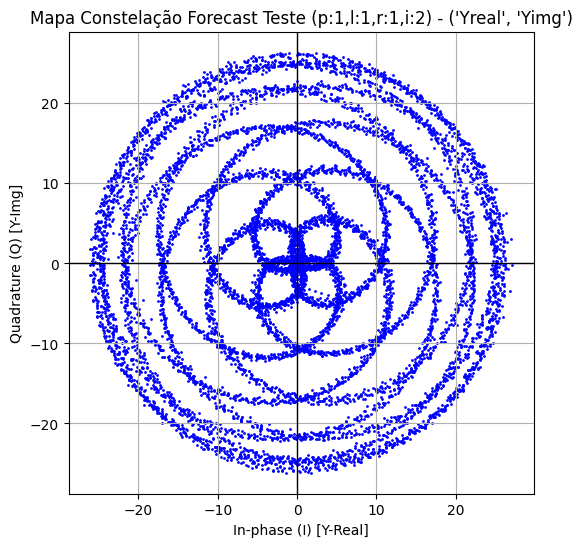

In [ ]:
# Mapas de Constelação dos dados de Teste Reais e Forecast
drawn_constellation_map(test,title="Mapa Constelação Dados Originais (Teste)")
drawn_constellation_map(fc_test,title="Mapa Constelação Forecast Teste (p:1,l:1,r:1,i:2)")

## Realizando Forecast Total dos Dados e Gerando Mapa de Magnetude

In [ ]:
# ----------------------------
# Geração do Mapa de Magnetude
# ----------------------------
def drawn_magnitude_map(df_input,forecast,endog_cols=('Yreal','Yimg'),exog_cols=('Xreal','Ximg'),title="Mapa de Magnitude"):
  df_mag = pd.DataFrame()
  df_mag["MAG_Input"] = np.sqrt(df_input[exog_cols[0]]**2 + df_input[exog_cols[1]]**2)
  df_mag["MAG_Output_forecast"] = np.sqrt(forecast[endog_cols[0]]**2 + forecast[endog_cols[1]]**2)

  df_mag["MAG_Input_Decibel"] = 20*np.log10(df_mag["MAG_Input"])
  df_mag["MAG_Output_Decibel_forecast"] = 20*np.log10(df_mag["MAG_Output_forecast"])

  plt.plot(df_mag["MAG_Input_Decibel"],df_mag["MAG_Output_Decibel_forecast"],marker='o')
  plt.xlabel("MAG Input [dB]")
  plt.ylabel("MAG Output Forecast [dB]")
  plt.title(f"{title}")
  plt.grid(True)
  img_label = title.replace(" ","-").lower()
  plt.savefig(f"{img_label}.png")
  plt.show()

(29029, 8)


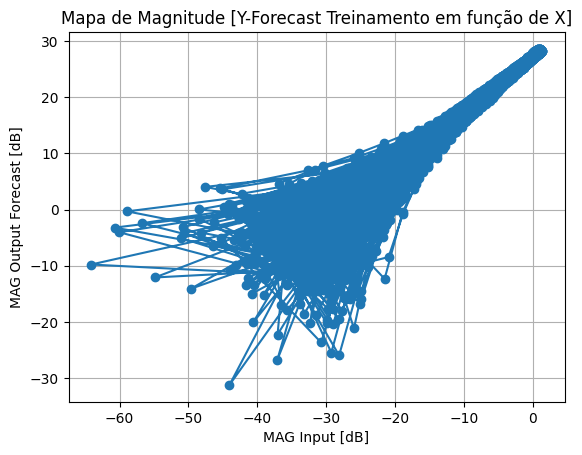

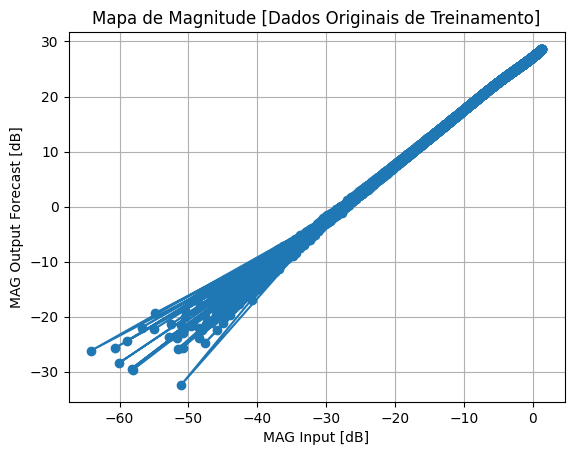

In [ ]:
# Gerando Mapa de Magnitude para Dados de Treino (Originais e Forecast)
drawn_magnitude_map(df_train_test,fc_train,title="Mapa de Magnitude [Y-Forecast Treinamento em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais de Treinamento]")

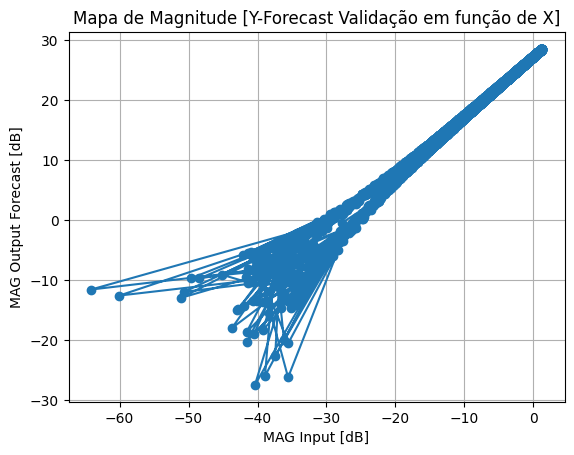

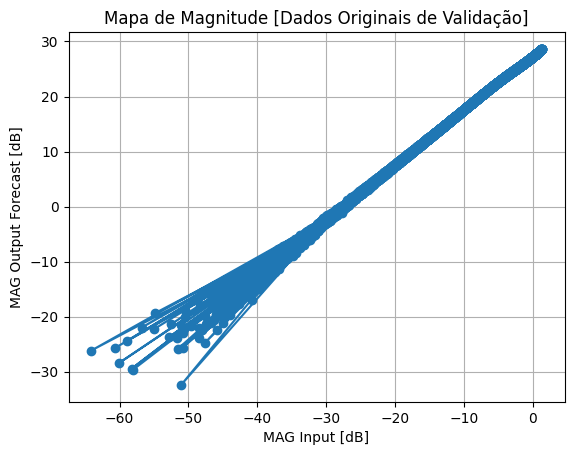

In [ ]:
# Gerando Mapa de Magnitude para Dados de Validação (Originais e Forecast)
drawn_magnitude_map(df_train_test,fc_val,title="Mapa de Magnitude [Y-Forecast Validação em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais de Validação]")

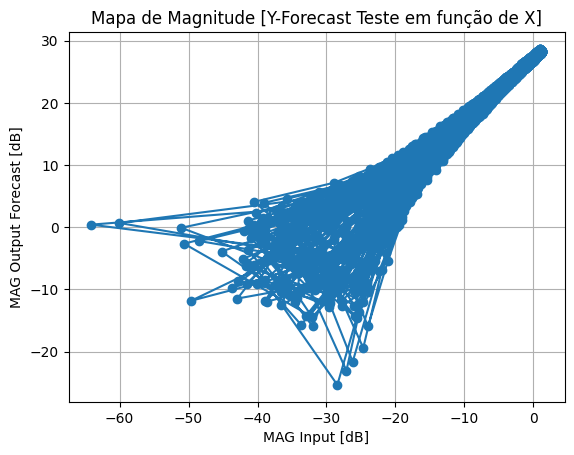

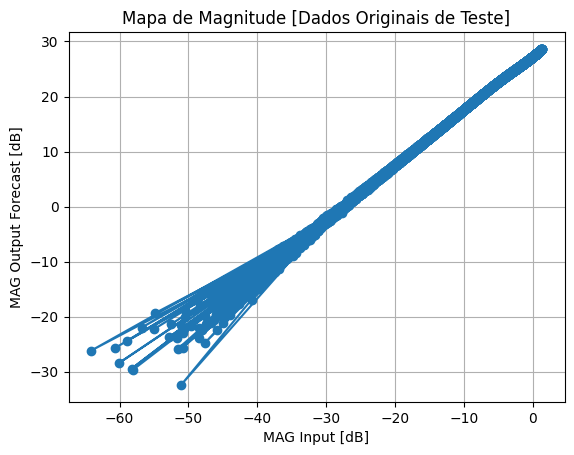

In [ ]:
# Gerando Mapa de Magnitude para Dados de Teste (Originais e Forecast)
drawn_magnitude_map(df_train_test,fc_test,title="Mapa de Magnitude [Y-Forecast Teste em função de X]")
drawn_magnitude_map(df_train_test,df_train_test,title="Mapa de Magnitude [Dados Originais de Teste]")

In [ ]:
# Realizando o forecast de todos os dados
endog_total = df_train_test[list(["Yreal","Yimg"])]
exog_total = df_train_test[list(current_exog_cols)]

fc_total = final_res.forecast(steps=len(endog_total),exog=exog_total)
fc_total.index = endog_total.index

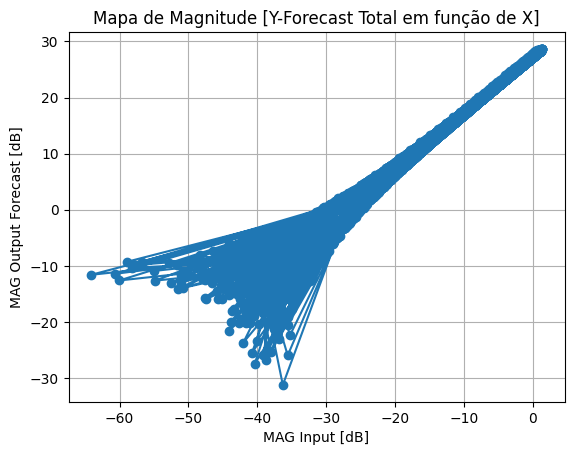

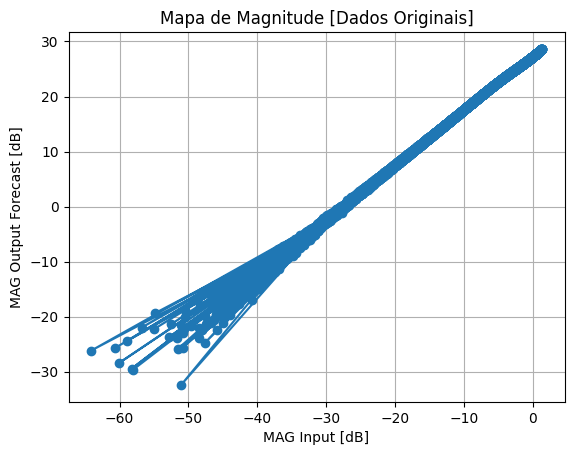

In [ ]:
# Gerando Mapa de Magnitude
drawn_magnitude_map(df_concat,fc_total,title="Mapa de Magnitude [Y-Forecast Total em função de X]")
drawn_magnitude_map(df_concat,df_concat,title="Mapa de Magnitude [Dados Originais]")

## Reorganizando dados de Validação e Teste e aplicando Forecast

In [82]:
# Gerando DataFrame com Dados de Validação e Teste
df_val_test = pd.concat([val,test])
print(f"shape: {df_val_test.shape}")

df_val_test10 = df_val_test.loc[df_val_test.index.repeat(10)].reset_index(drop=True)
print(f"shape: {df_val_test10.shape}")

df_val_test = df_val_test10.sample(frac=1,random_state=42).reset_index(drop=True)
print(f"shape: {df_val_test.shape}")

shape: (19353, 8)
shape: (193530, 8)
shape: (193530, 8)


In [83]:
# Gerando forecast sobre dadods Aleatórios
fc_random = final_res.forecast(steps=len(df_val_test),exog=df_val_test[current_exog_cols])

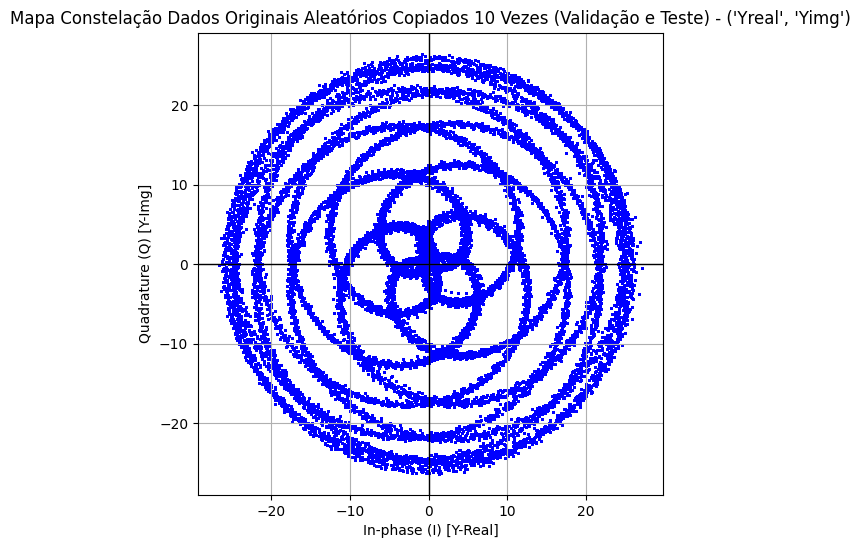

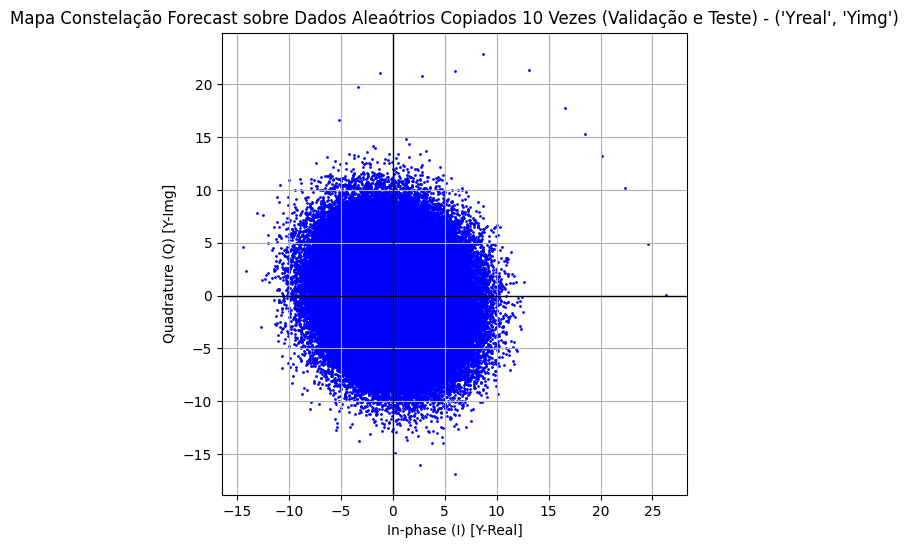

In [84]:
# Gerando Mapas de Constelação para Dados Randomicos Originais e com Forecast
drawn_constellation_map(df_val_test,title="Mapa Constelação Dados Originais Aleatórios Copiados 10 Vezes (Validação e Teste)")
drawn_constellation_map(fc_random,title="Mapa Constelação Forecast sobre Dados Aleaótrios Copiados 10 Vezes (Validação e Teste)")

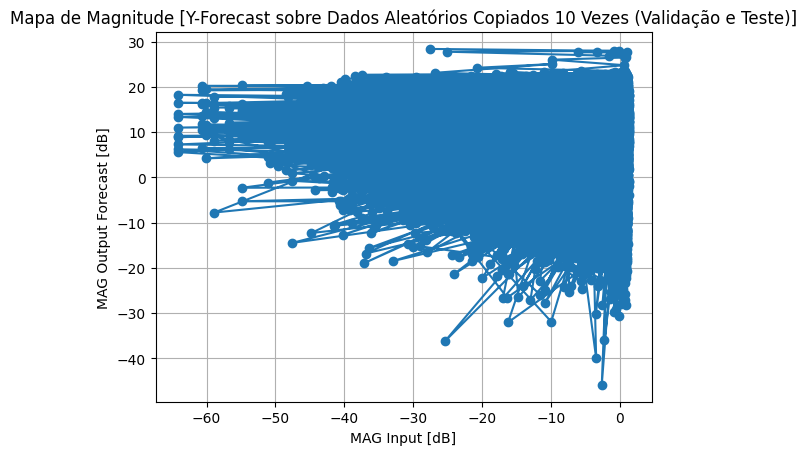

In [85]:
# Gerando Mapa de Magnitude sobre Dados Randomicos
drawn_magnitude_map(df_val_test,fc_random,title="Mapa de Magnitude [Y-Forecast sobre Dados Aleatórios Copiados 10 Vezes (Validação e Teste)]")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')